In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('..\\data\\smallseg_bathy.csv')
df.head()

,long,lat,bathy
0,-127.497917,45.002083,-2948
1,-127.493750,45.002083,-2951
2,-127.489583,45.002083,-2954
3,-127.485417,45.002083,-2960
4,-127.481250,45.002083,-2961


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [4]:
x = df.drop(columns=['bathy'])
y = df['bathy']

In [5]:
x.head()

,long,lat
0,-127.497917,45.002083
1,-127.493750,45.002083
2,-127.489583,45.002083
3,-127.485417,45.002083
4,-127.481250,45.002083


In [6]:
x.shape

(14400, 2)

In [7]:
y.head()

0   -2948
1   -2951
2   -2954
3   -2960
4   -2961
Name: bathy, dtype: int64

In [8]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [9]:
x_train.shape

(11520, 2)

this is the raw validation data

In [10]:
x_test.shape

(2880, 2)

In [11]:
x_train.describe().round(3)

,long,lat
count,11520.000,11520.000
mean,-127.250,45.249
std,0.144,0.145
min,-127.498,45.002
25%,-127.373,45.123
50%,-127.248,45.248
75%,-127.127,45.373
max,-127.002,45.498


In [12]:
x_test.describe().round(3)

,long,lat
count,2880.000,2880.000
mean,-127.251,45.253
std,0.145,0.144
min,-127.498,45.002
25%,-127.381,45.127
50%,-127.252,45.252
75%,-127.123,45.377
max,-127.002,45.498


In [13]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

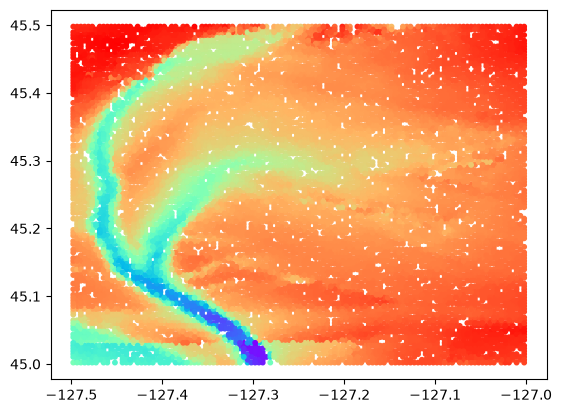

In [14]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

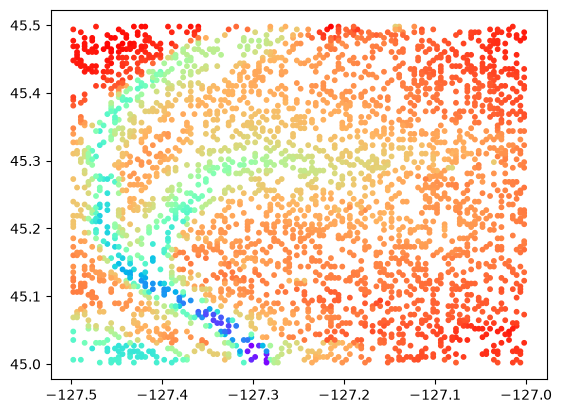

In [15]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [14]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [15]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 242
[LightGBM] [Info] Number of data points in the train set: 11520, number of used features: 2
[LightGBM] [Info] Start training from score -2884.831597


In [16]:
y_pred = model.predict(x_test)

In [17]:
y_pred.shape

(2880,)

In [18]:
y_pred, y_pred.shape

(array([-2858.27123547, -2880.7107176 , -2882.73804059, ...,
        -2908.62653181, -2882.02730079, -2891.37537185], shape=(2880,)),
 (2880,))

In [19]:
residuals = y_test - y_pred

negative mean: overpredicting

In [20]:
residuals.head(), residuals.describe()

(10680    1.271235
 9016    -4.289282
 6187     1.738041
 13525    0.524683
 2616    -1.088756
 Name: bathy, dtype: float64,
 count    2880.000000
 mean        0.092245
 std         6.628775
 min       -50.560128
 25%        -1.659678
 50%         0.046921
 75%         1.989192
 max        51.624118
 Name: bathy, dtype: float64)

In [21]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [22]:
pd.DataFrame(dfr).to_csv('..\\created_data\\smallseg_bathy_residuals.csv', index=False)

with open('..\\created_data\\smallseg_bathy_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

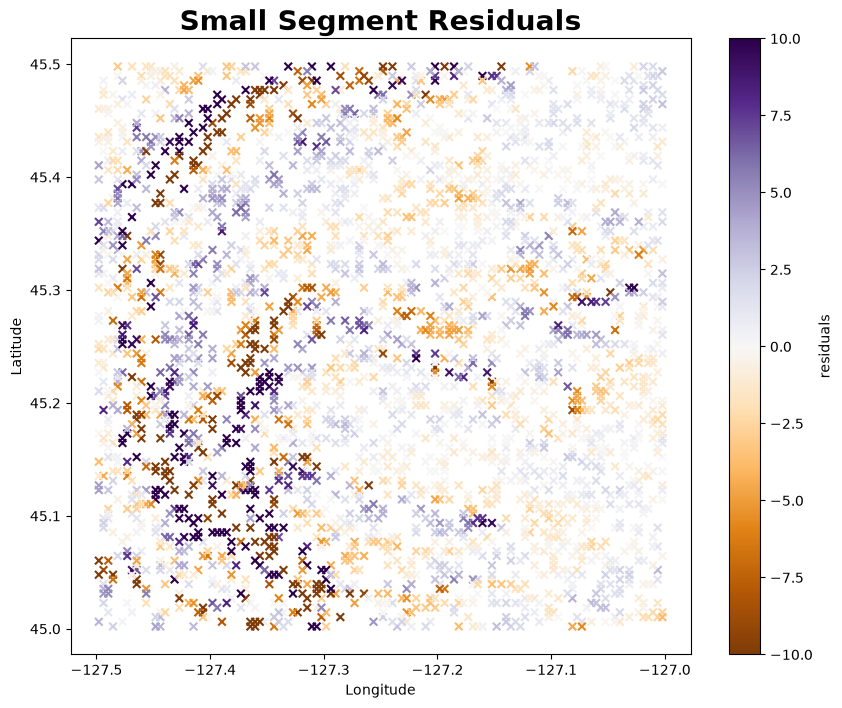

In [23]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Small Segment Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\smallseg_bathy.png', dpi=400)
plt.show()

In [24]:
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), 200)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), 200)

In [25]:
long, lat = np.meshgrid(grid_long, grid_lat)

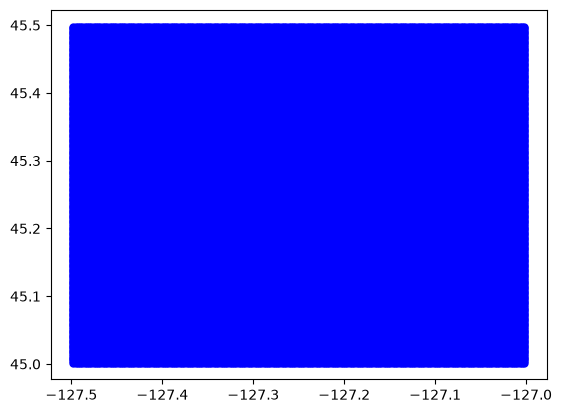

In [26]:
plt.plot(long, lat, marker='o', markersize=5, color='blue', linestyle='none')
plt.show()

In [27]:
lola = np.vstack([long.ravel(), lat.ravel()]).T

In [28]:
lola_pred = model.predict(lola)

In [29]:
lola_pred.shape

(40000,)

reshaping the (2500,) pred dadtaset into 50 rows, 50 columns which we would specify the step in linspace

In [30]:
lola_pred = lola_pred.reshape(long.shape)

In [31]:
lola_pred.shape

(200, 200)

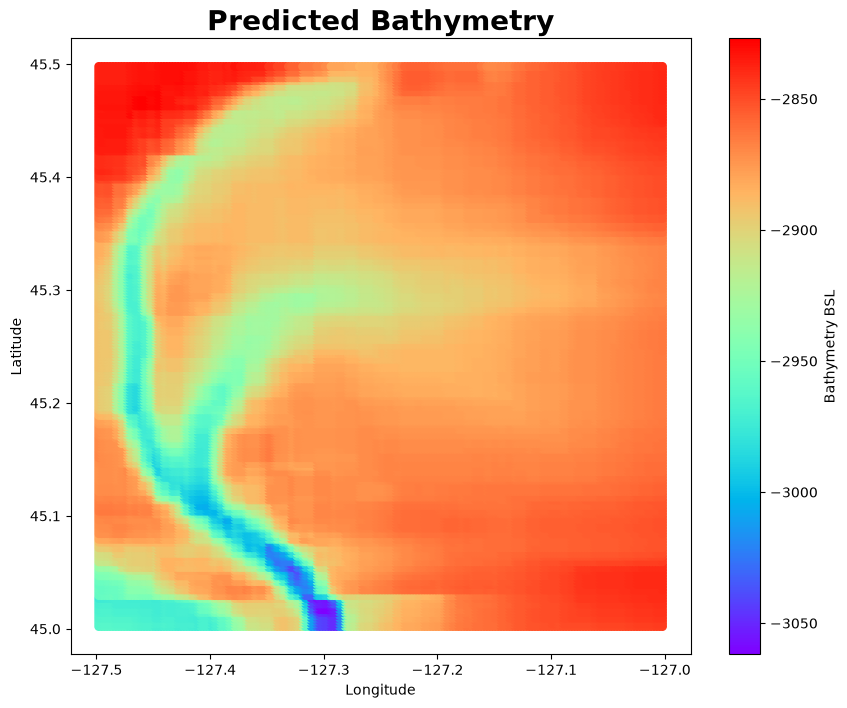

In [32]:
plt.figure(figsize=(10, 8))
plt.scatter(long, lat, c=lola_pred.reshape(long.shape), cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Bathymetry BSL')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Bathymetry', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\smallseg_pred_bathy_200.png', dpi=400)
plt.show()